In [14]:
import torch
import torch.nn as nn

try:
    from torch_geometric.datasets import MoleculeNet
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import MessagePassing, global_add_pool
except ImportError:
    print("Installing torch_geometric...")
    !pip install torch_geometric
    from torch_geometric.datasets import MoleculeNet
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import MessagePassing, global_add_pool

In [15]:
!pip install rdkit
from rdkit import Chem

In [ ]:
from torch_geometric.transforms import BaseTransform
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from rdkit import Chem
from rdkit.Chem import Descriptors
import torch

class MultiTaskFeaturizer(BaseTransform):
    def forward(self, data):
        mol = Chem.MolFromSmiles(data.smiles)
        if mol is None: return data

        # 1. NEW SECONDARY TARGET: Molecular Weight (The "Pre-training" signal)
        # We scale by 100 to keep the MSE loss in a similar range to LogP
        data.mw = torch.tensor([Descriptors.MolWt(mol) / 100.0], dtype=torch.float)

        # 2. NEW GLOBAL FEATURE: TPSA (Context for every atom)
        tpsa = Descriptors.TPSA(mol) / 500.0

        # Measures how 3D a molecule is
        f_csp3 = Descriptors.FractionCSP3(mol)

        new_x = []
        for i, atom in enumerate(mol.GetAtoms()):
            # BASELINE: Your existing 12 features (One-hot + Ring + Aromatic + H_count) standardized to all binary values
            baseline_features = [1.0 if val > 0 else 0.0 for val in data.x[i].tolist()]

            # STRUCTURAL: Redefining your logic here to ensure it's captured
            is_ring = 1.0 if atom.IsInRing() else 0.0
            is_aromatic = 1.0 if atom.GetIsAromatic() else 0.0
            h_count_scaled = float(atom.GetTotalNumHs()) / 4.0

            # BIOLOGICAL: Adding the new "Bio-Pro" drivers
            formal_charge = float(atom.GetFormalCharge())

            # COMBINE: 9(Baseline) + 3(Structural) + 2(Bio) + 1(Shape) = 15 total features
            atom_features = baseline_features + [is_ring, is_aromatic, h_count_scaled, formal_charge, tpsa, f_csp3]
            new_x.append(atom_features)

        data.x = torch.tensor(new_x, dtype=torch.float)
        return data

# Reload with Multi-Task implementation
# force_reload=True is critical here to overwrite the old 12-feature processed data
dataset = MoleculeNet(root='.', name='lipo', pre_transform=MultiTaskFeaturizer(), force_reload=True)

# Re-split (3600 for train as per your previous setup)
train_loader = DataLoader(dataset[:3600], batch_size=32, shuffle=True)
test_loader = DataLoader(dataset[3600:], batch_size=32)

print(f"Data ready. Input features: {dataset.num_node_features}") # Should be 14

Processing...


Data ready. Input features: 15


Done!


In [ ]:
# 2. DMPNN LAYER
# This passes messages from edges to edges, preventing "backtracking"
class DMPNNConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add', flow='source_to_target')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        # We integrate edge features into the message passing
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_j, edge_attr):
        # Combining neighboring atom features with bond features
        return F.relu(self.lin(x_j + edge_attr))

In [ ]:
# 3. FULL MODEL ARCHITECTURE

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import global_add_pool

from torch_geometric.nn import GATv2Conv, global_add_pool

class BioAttentionDMPNN(nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_dim, tasks=['logp', 'mw']):
        super(BioAttentionDMPNN, self).__init__()

        # 1. Initial Embeddings
        self.node_emb = nn.Linear(num_node_features, hidden_dim)
        self.edge_emb = nn.Linear(num_edge_features, hidden_dim)

        # 2. GATv2 Layers (Replacing DMPNNConv)
        # heads=4 allows the model to look at 4 different chemical patterns at once
        self.conv1 = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=hidden_dim) # Changed hidden_dim // 4 to hidden_dim // 2
        self.ln1 = nn.LayerNorm(hidden_dim)

        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=hidden_dim) # Changed hidden_dim // 4 to hidden_dim // 2
        self.ln2 = nn.LayerNorm(hidden_dim)

        # 3. Virtual Node Logic
        # This aggregates information from all atoms and redistributes it
        self.virtual_node_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # 4. Malleable Head Factory
        self.fc_shared = nn.Linear(hidden_dim, hidden_dim // 2)
        self.heads = nn.ModuleDict({
            task: nn.Linear(hidden_dim // 2, 1) for task in tasks
        })

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x.float(), data.edge_index, data.edge_attr.float(), data.batch

        # Initial projection
        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))

        # --- Layer 1 with Virtual Node Update ---
        # A) Message Passing
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(self.ln1(x))

        # B) Virtual Node Update (Global Communication)
        v_node = global_add_pool(x, batch) # Aggregate all atoms
        v_node = self.virtual_node_mlp(v_node) # Process global state
        x = x + v_node[batch] # Broadcast back to every atom

        # --- Layer 2 ---
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(self.ln2(x))
        x = F.dropout(x, p=0.2, training=self.training)

        # Readout
        x_graph = global_add_pool(x, batch)
        x_graph = F.relu(self.fc_shared(x_graph))

        # Dictionary Return for Malleability
        return {task: self.heads[task](x_graph) for task in self.heads}

In [ ]:
# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Automatically detect new feature size from your transformed dataset
# Since you used the Phase 1 Featurizer, this will now correctly detect 13 features
input_dim = dataset.num_node_features
edge_dim = dataset.num_edge_features

# 3. Re-initialize the model with higher capacity (128 units instead of 64)
# Use 'DMPNNModel' as defined in your Cell 7
model = BioAttentionDMPNN(input_dim, edge_dim, 128).to(device)

# 4. Re-initialize optimizer with a smaller learning rate (0.0005) for stability
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay = 1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

def train():
    model.train()
    total_loss = 0
    # Weights for multi-tasking
    weights = {'logp': 1.0, 'mw': 0.2}

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        out_dict = model(data)

        # Calculate weighted loss dynamically
        loss_logp = criterion(out_dict['logp'].view(-1), data.y.view(-1))
        loss_mw = criterion(out_dict['mw'].view(-1), data.mw.view(-1))

        loss = (weights['logp'] * loss_logp) + (weights['mw'] * loss_mw)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

In [ ]:
print(torch.cuda.is_available())

True


In [16]:
loss_history = []  # List to store loss values

print("Starting training...")
for epoch in range(1, 101):
    loss = train()
    scheduler.step(loss)
    loss_history.append(loss)  # Save the loss for plotting

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}')

Starting training...
Epoch 010, Loss: 0.4184
Epoch 020, Loss: 0.3758
Epoch 030, Loss: 0.3032
Epoch 040, Loss: 0.3226
Epoch 050, Loss: 0.2523
Epoch 060, Loss: 0.2250
Epoch 070, Loss: 0.2221
Epoch 080, Loss: 0.1824
Epoch 090, Loss: 0.1764
Epoch 100, Loss: 0.1613


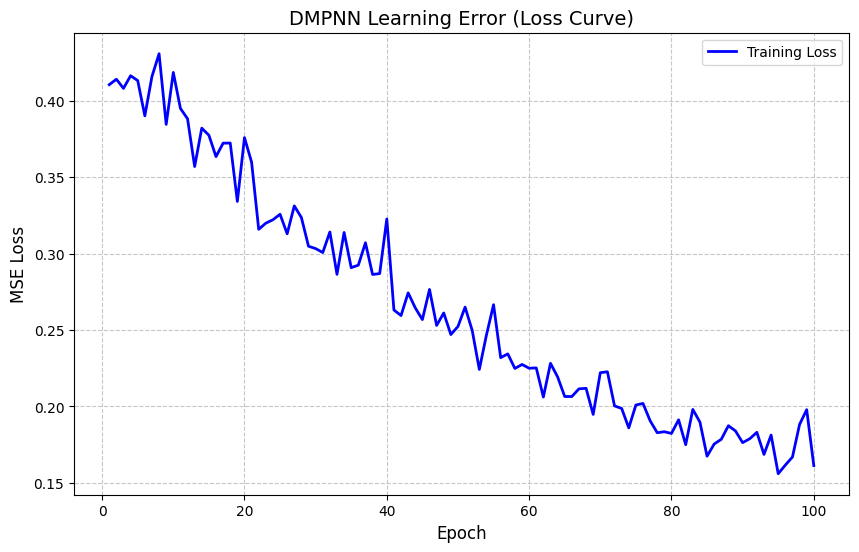

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), loss_history, label='Training Loss', color='blue', linewidth=2)

# Formatting the plot
plt.title('DMPNN Learning Error (Loss Curve)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def test():
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out_dict = model(data)

            # Specifically pull 'logp' for the final metrics
            all_preds.append(out_dict['logp'].view(-1).cpu().numpy())
            all_targets.append(data.y.view(-1).cpu().numpy())

    # Flatten results
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Calculate Metrics (using sklearn for proper R2 calculation)
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)

    print(f"\n--- TEST SET RESULTS ---")
    print(f"MAE:  {mae:.4f} (Average error in LogP units)")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f} (Correlation)")

    return all_targets, all_preds

# Run the test
targets, predictions = test()


--- TEST SET RESULTS ---
MAE:  0.6240 (Average error in LogP units)
RMSE: 0.8265
R²:   0.5274 (Correlation)
